# Part II - Ford GoBike (Feb 2019): Subscriber vs Customer Riding Patterns
## by Romaine Vassell


### Theme / Overarching question
**How do riding patterns differ between Subscribers and Customers, and what does that imply about how the bike-share system is used?**

### Dataset context
- Ford GoBike trip records for **February 2019** (San Francisco Bay Area)
- Each row is one trip: duration, time-of-day, start/end stations, and rider type/demographics

In this presentation, I focus on a small set of insights that best summarize the exploratory findings.


In [4]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

%matplotlib inline

# plotting defaults
sb.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [3]:
import os
os.getcwd()

'/Users/djromie/Desktop/Project Data'

In [14]:
# load in the dataset into a pandas dataframe
df = pd.read_csv("FordGoBikeSystemData.csv")

In [15]:
# prepare data (same approach as Part I)
df["start_time"] = pd.to_datetime(df["start_time"])
df["duration_min"] = df["duration_sec"] / 60
df["hour"] = df["start_time"].dt.hour
df["member_gender"] = df["member_gender"].fillna("Unknown")

df["age"] = df["start_time"].dt.year - df["member_birth_year"]

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1 = np.radians(lat1); phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1); dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine_km(
    df["start_station_latitude"], df["start_station_longitude"],
    df["end_station_latitude"], df["end_station_longitude"]
)

# Cap durations for clear visuals
df_pres = df[df["duration_min"].between(1, 60)].copy()

df_pres.head()


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,duration_min,hour,age,distance_km
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,26.416667,23,45.0,2.409301
5,1793,2019-02-28 23:49:58.632,2019-03-01 00:19:51.7600,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No,29.883333,23,60.0,3.332203
6,1147,2019-02-28 23:55:35.104,2019-03-01 00:14:42.5880,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No,19.116667,23,36.0,2.028551
7,1615,2019-02-28 23:41:06.766,2019-03-01 00:08:02.7560,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No,26.916667,23,30.0,4.532568
8,1570,2019-02-28 23:41:48.790,2019-03-01 00:07:59.7150,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No,26.166667,23,31.0,4.532568


> Note that the above cells have been set as "Skip"-type slides. That means
that when the notebook is rendered as http slides, those cells won't show up.

## Visualization 1: Subscribers dominate commute-hours

**Design choice:** Use a line plot of trip counts by hour and split by user type to show usage patterns clearly.

**Key takeaway:** Subscriber activity peaks during typical commute times (morning and late afternoon), consistent with routine transportation use.


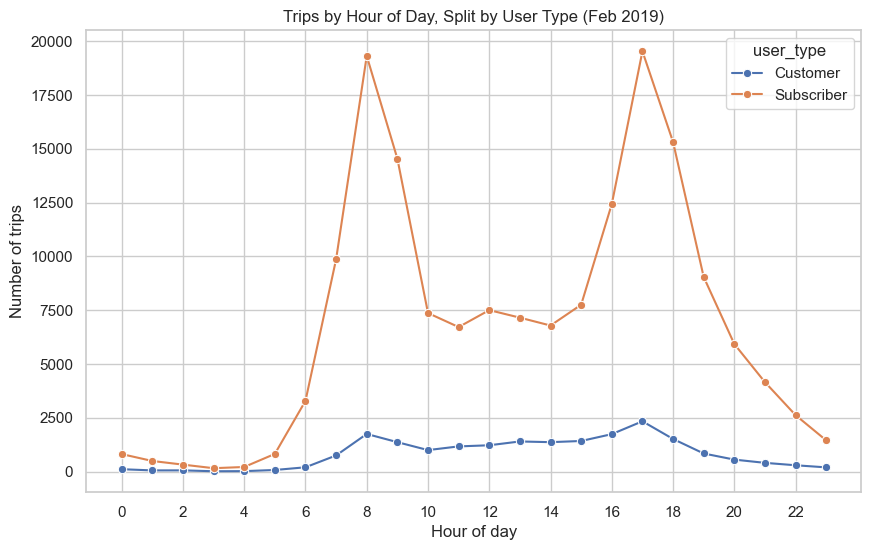

In [6]:
# Trips by hour, split by user type
hourly = df.groupby(["hour", "user_type"]).size().reset_index(name="trips")

plt.figure()
sb.lineplot(data=hourly, x="hour", y="trips", hue="user_type", marker="o")
plt.title("Trips by Hour of Day, Split by User Type (Feb 2019)")
plt.xlabel("Hour of day")
plt.ylabel("Number of trips")
plt.xticks(range(0, 24, 2))
plt.show()


## Visualization 2: Customers take longer trips than Subscribers

**Design choice:** Box plot (capped at 60 minutes) highlights differences in median and spread without overplotting.

**Key takeaway:** Customers show a higher median trip duration and greater variability, suggesting more leisure / exploration usage.


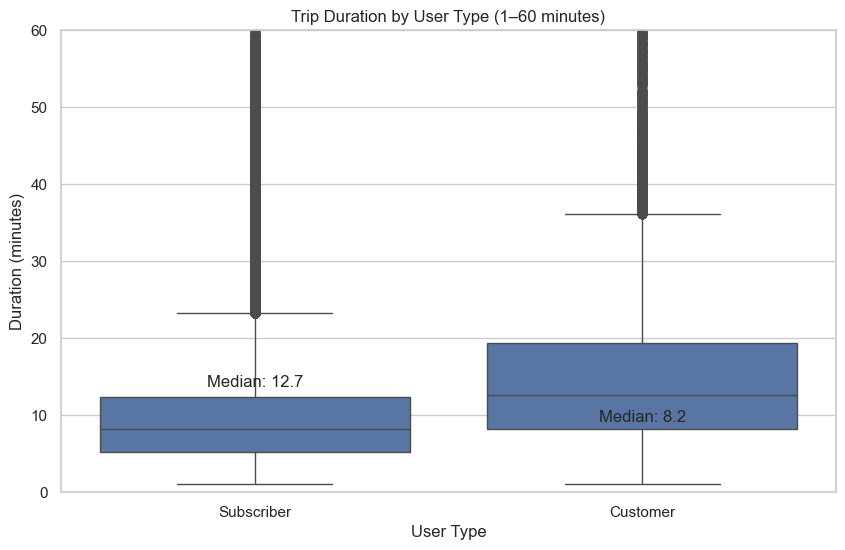

In [7]:
plt.figure()
sb.boxplot(data=df_pres, x="user_type", y="duration_min")
plt.title("Trip Duration by User Type (1–60 minutes)")
plt.xlabel("User Type")
plt.ylabel("Duration (minutes)")
plt.ylim(0, 60)

# annotate medians
medians = df_pres.groupby("user_type")["duration_min"].median()
for i, ut in enumerate(medians.index):
    plt.text(i, medians[ut] + 1, f"Median: {medians[ut]:.1f}", ha="center")

plt.show()


## Visualization 3: Duration increases with distance, but user type remains the clearest separator

**Design choice:** Scatterplot with multiple encodings (color = user type, style = gender) supports the relationship while keeping the focus on user type.

**Key takeaway:** Distance and duration are related, but Customers still trend longer even for similar distances.


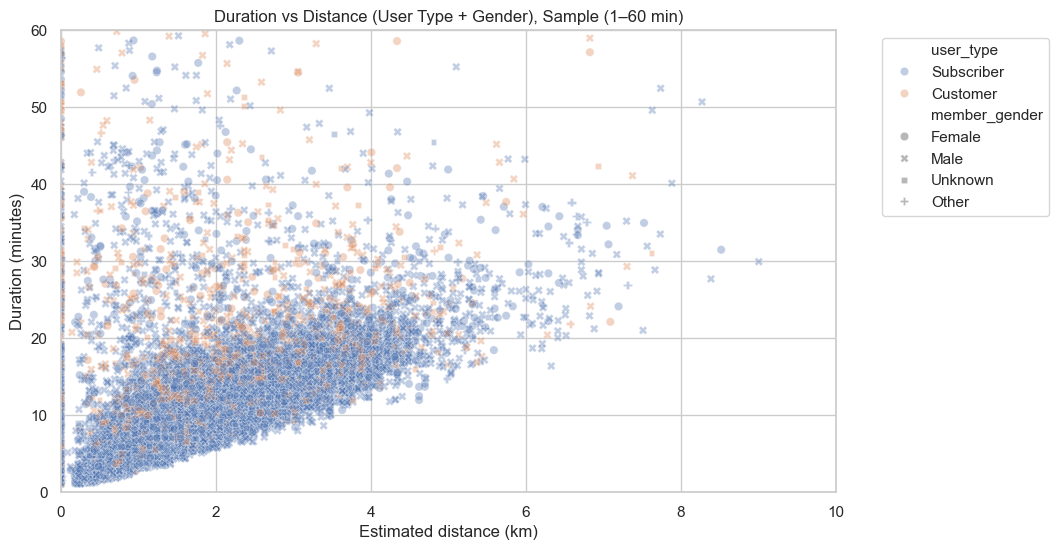

In [8]:
plt.figure()
sample_df = df_pres.sample(20000, random_state=42)

sb.scatterplot(
    data=sample_df,
    x="distance_km",
    y="duration_min",
    hue="user_type",
    style="member_gender",
    alpha=0.35
)

plt.title("Duration vs Distance (User Type + Gender), Sample (1–60 min)")
plt.xlabel("Estimated distance (km)")
plt.ylabel("Duration (minutes)")
plt.xlim(0, 10)
plt.ylim(0, 60)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


>**Generate Slideshow**: Once you're ready to generate your slideshow, use the `jupyter nbconvert` command to generate the HTML slide show. . From the terminal or command line, use the following expression.

In [11]:
!jupyter nbconvert <Part_II_FordGoBike_Slide_Deck.ipynb> --to slides --post serve --no-input --no-prompt

[NbConvertApp] WARNING | pattern 'slides' matched no files


> This should open a tab in your web browser where you can scroll through your presentation. Sub-slides can be accessed by pressing 'down' when viewing its parent slide. Make sure you remove all of the quote-formatted guide notes like this one before you finish your presentation! At last, you can stop the Kernel. 

## Summary / Executive conclusion

- The system is heavily used by **Subscribers**, with clear **commute-hour peaks**.
- **Customers** take **longer and more variable** trips, consistent with leisure riding.
- While **distance and duration** move together, **user type** remains the strongest differentiator in trip behavior.

**Implication:** Operational planning (bike rebalancing, maintenance timing) should prioritize commute peaks for Subscribers, while marketing and pricing for Customers may focus on longer leisure rides.
